Всего извлечено временных меток: 1039
Всего интервалов: 1038
Межпачечных интервалов (> 180 с): 47
Средний межпачечный интервал: 1115.7 секунд
Минимальный межпачечный: 674.0 с, максимальный: 1228.0 с


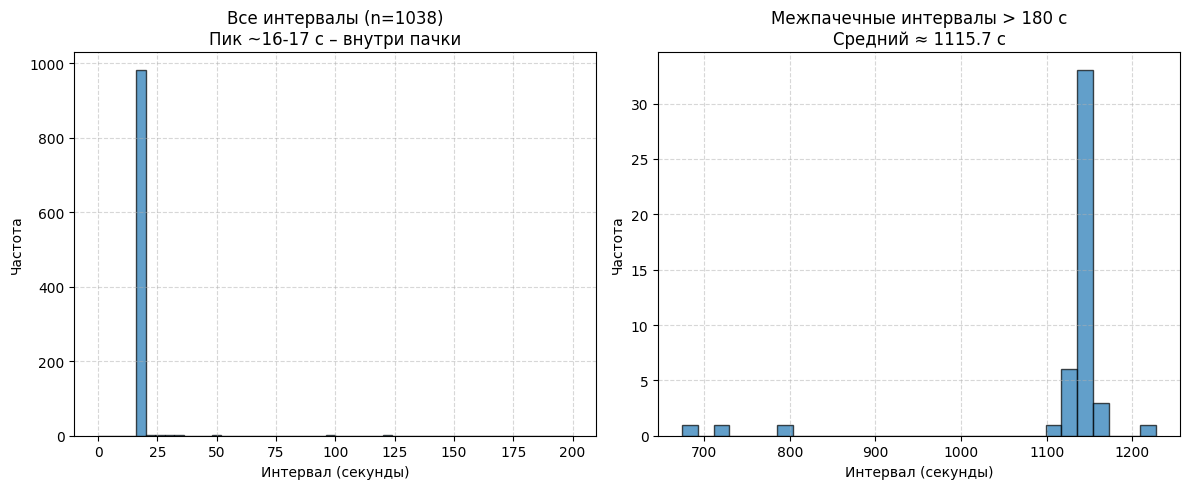

In [1]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

def parse_timestamps(file_path):
    """
    Читает файл построчно, извлекает server_received_at из поля head_sens.
    Возвращает отсортированный список datetime-объектов.
    """
    timestamps = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
                # Поле может быть на верхнем уровне (server_received_at) или внутри head_sens
                if 'head_sens' in data and 'server_received_at' in data['head_sens']:
                    ts_str = data['head_sens']['server_received_at']
                elif 'server_received_at' in data:
                    ts_str = data['server_received_at']
                else:
                    # Пропускаем строки без нужного поля (например, ошибки)
                    continue
                timestamps.append(datetime.fromisoformat(ts_str))
            except (json.JSONDecodeError, ValueError) as e:
                # Игнорируем битые строки (например, ошибки дешифровки)
                print(f"Ошибка в строке {line_num}: {e}")
                continue
    timestamps.sort()
    return timestamps

def compute_intervals(timestamps):
    """Возвращает список интервалов в секундах между последовательными временами."""
    intervals = []
    for i in range(1, len(timestamps)):
        delta = (timestamps[i] - timestamps[i-1]).total_seconds()
        intervals.append(delta)
    return intervals

def plot_histograms(all_intervals, interburst_intervals, threshold=180):
    """
    Строит две гистограммы:
    1. Все интервалы (с ограничением по оси X до 200 с, чтобы видеть основную частоту).
    2. Только интервалы > threshold (межпачечные).
    """
    # ---- Гистограмма всех интервалов ----
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.hist(all_intervals, bins=50, range=(0, 200), edgecolor='black', alpha=0.7)
    plt.xlabel('Интервал (секунды)')
    plt.ylabel('Частота')
    plt.title(f'Все интервалы (n={len(all_intervals)})\nПик ~16-17 с – внутри пачки')
    plt.grid(True, linestyle='--', alpha=0.5)

    # ---- Гистограмма межпачечных интервалов ----
    plt.subplot(1, 2, 2)
    if interburst_intervals:
        plt.hist(interburst_intervals, bins=30, edgecolor='black', alpha=0.7)
        plt.xlabel('Интервал (секунды)')
        plt.ylabel('Частота')
        plt.title(f'Межпачечные интервалы > {threshold} с\nСредний ≈ {sum(interburst_intervals)/len(interburst_intervals):.1f} с')
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        plt.text(0.5, 0.5, 'Нет интервалов больше порога', ha='center', va='center')

    plt.tight_layout()
    plt.show()

def main():
    file_path = 'data_decoded.txt'   # Укажите путь к вашему файлу
    timestamps = parse_timestamps(file_path)
    print(f"Всего извлечено временных меток: {len(timestamps)}")

    if len(timestamps) < 2:
        print("Недостаточно данных для построения гистограмм.")
        return

    intervals = compute_intervals(timestamps)

    # Отделяем интервалы, превышающие 3 минуты (180 секунд)
    threshold = 180
    interburst = [i for i in intervals if i > threshold]

    print(f"Всего интервалов: {len(intervals)}")
    print(f"Межпачечных интервалов (> {threshold} с): {len(interburst)}")
    if interburst:
        print(f"Средний межпачечный интервал: {sum(interburst)/len(interburst):.1f} секунд")
        print(f"Минимальный межпачечный: {min(interburst):.1f} с, максимальный: {max(interburst):.1f} с")

    plot_histograms(intervals, interburst, threshold)

if __name__ == "__main__":
    main()

Всего извлечено временных меток: 1039
Всего интервалов: 1038
Межпачечных интервалов (> 180 с): 47
Средний межпачечный интервал: 1115.7 секунд


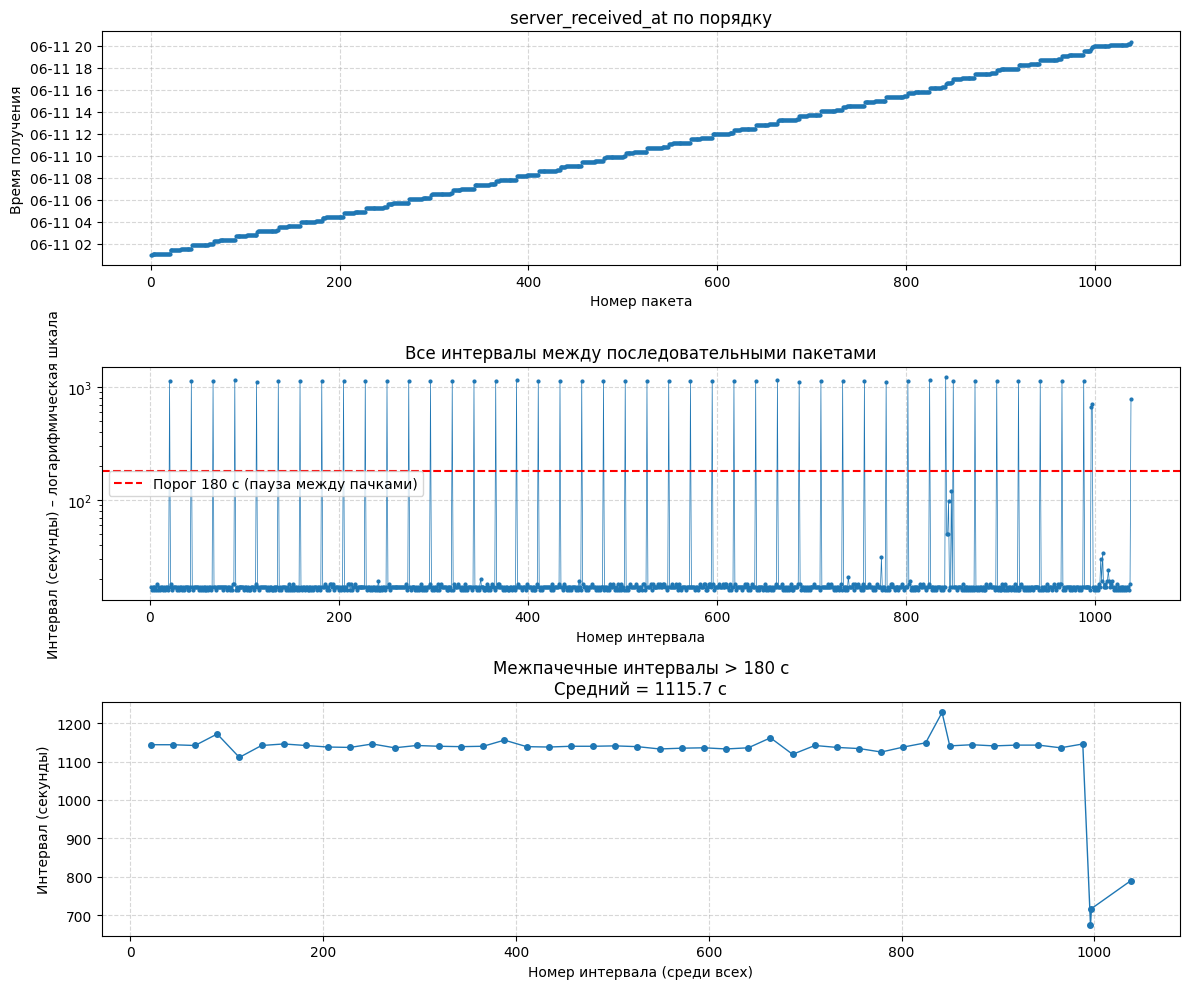

In [2]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

def parse_timestamps(file_path):
    """Извлекает server_received_at из каждой строки, возвращает отсортированный список datetime."""
    timestamps = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
                # Ищем поле server_received_at (может быть на верхнем уровне или внутри head_sens)
                if 'head_sens' in data and 'server_received_at' in data['head_sens']:
                    ts_str = data['head_sens']['server_received_at']
                elif 'server_received_at' in data:
                    ts_str = data['server_received_at']
                else:
                    continue
                timestamps.append(datetime.fromisoformat(ts_str))
            except (json.JSONDecodeError, ValueError):
                continue
    timestamps.sort()
    return timestamps

def compute_intervals(timestamps):
    """Возвращает список интервалов в секундах между последовательными временами."""
    intervals = []
    for i in range(1, len(timestamps)):
        delta = (timestamps[i] - timestamps[i-1]).total_seconds()
        intervals.append(delta)
    return intervals

def plot_line_graphs(timestamps, intervals, interburst_intervals, threshold=180):
    """
    Строит три графика:
    1. Все временные метки (server_received_at) по порядку.
    2. Все интервалы (по номеру).
    3. Только межпачечные интервалы (по номеру среди всех интервалов).
    """
    # ---- 1. Временные метки ----
    plt.figure(figsize=(12, 10))

    plt.subplot(3, 1, 1)
    plt.plot(range(len(timestamps)), timestamps, 'o-', markersize=2, linewidth=0.5)
    plt.xlabel('Номер пакета')
    plt.ylabel('Время получения')
    plt.title('server_received_at по порядку')
    plt.grid(True, linestyle='--', alpha=0.5)

    # ---- 2. Все интервалы ----
    plt.subplot(3, 1, 2)
    # Используем логарифмическую шкалу Y, чтобы видеть и короткие (~16 с), и длинные (~1000+ с) интервалы
    plt.semilogy(range(1, len(intervals)+1), intervals, 'o-', markersize=2, linewidth=0.5)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Порог {threshold} с (пауза между пачками)')
    plt.xlabel('Номер интервала')
    plt.ylabel('Интервал (секунды) – логарифмическая шкала')
    plt.title('Все интервалы между последовательными пакетами')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # ---- 3. Только межпачечные интервалы ----
    plt.subplot(3, 1, 3)
    if interburst_intervals:
        # Найдём номера интервалов, которые превышают порог
        indices = [i+1 for i, val in enumerate(intervals) if val > threshold]
        plt.plot(indices, interburst_intervals, 'o-', markersize=4, linewidth=1)
        plt.xlabel('Номер интервала (среди всех)')
        plt.ylabel('Интервал (секунды)')
        plt.title(f'Межпачечные интервалы > {threshold} с\nСредний = {sum(interburst_intervals)/len(interburst_intervals):.1f} с')
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        plt.text(0.5, 0.5, 'Нет интервалов больше порога', ha='center', va='center')

    plt.tight_layout()
    plt.show()

def main():
    file_path = 'data_decoded.txt'   # Укажите путь к вашему файлу
    timestamps = parse_timestamps(file_path)
    print(f"Всего извлечено временных меток: {len(timestamps)}")

    if len(timestamps) < 2:
        print("Недостаточно данных для построения графиков.")
        return

    intervals = compute_intervals(timestamps)
    threshold = 180
    interburst = [i for i in intervals if i > threshold]

    print(f"Всего интервалов: {len(intervals)}")
    print(f"Межпачечных интервалов (> {threshold} с): {len(interburst)}")
    if interburst:
        print(f"Средний межпачечный интервал: {sum(interburst)/len(interburst):.1f} секунд")

    plot_line_graphs(timestamps, intervals, interburst, threshold)

if __name__ == "__main__":
    main()

Всего корректных времен: 1033
Первый (самый ранний): 2026-06-11 00:36:13
Последний (самый поздний): 2026-06-11 20:09:10
Общий диапазон: 0 дней, 19 часов
Наиболее активный час: 13:00 (57 записей)


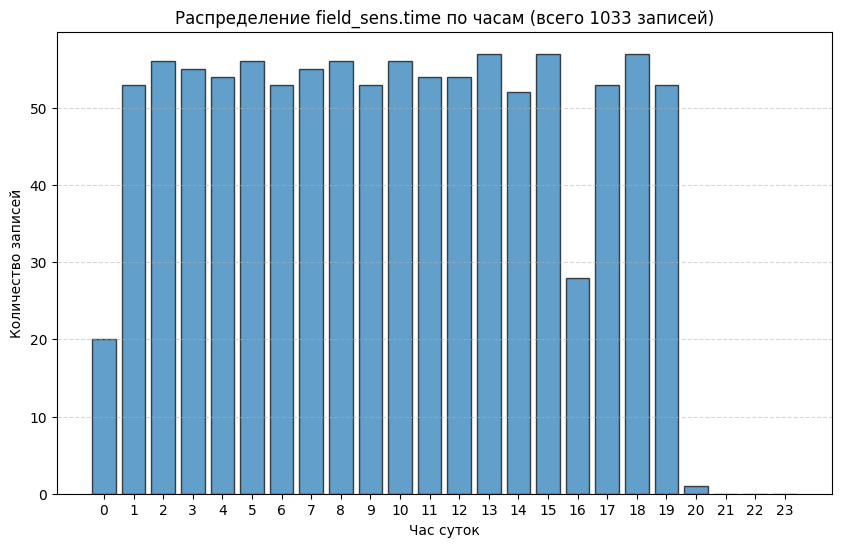

In [3]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

def parse_field_sens_times(file_path):
    """
    Извлекает значения field_sens.time из каждой строки JSON.
    Возвращает список datetime-объектов для корректных дат.
    """
    times = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
                if 'field_sens' in data and 'time' in data['field_sens']:
                    ts_str = data['field_sens']['time']
                    # Пропускаем заведомо невалидные значения
                    if ts_str.startswith('2000-00-00') or ts_str.startswith('2070-01-01'):
                        continue
                    # Пытаемся преобразовать в datetime
                    dt = datetime.fromisoformat(ts_str)
                    times.append(dt)
            except (json.JSONDecodeError, ValueError):
                continue
    return times

def plot_hour_histogram(times):
    """
    Строит гистограмму количества записей по часам суток.
    """
    if not times:
        print("Нет корректных времен для построения гистограммы.")
        return

    # Извлекаем часы (0-23)
    hours = [dt.hour for dt in times]

    plt.figure(figsize=(10, 6))
    plt.hist(hours, bins=24, range=(-0.5, 23.5), edgecolor='black', alpha=0.7, rwidth=0.8)
    plt.xlabel('Час суток')
    plt.ylabel('Количество записей')
    plt.title(f'Распределение field_sens.time по часам (всего {len(times)} записей)')
    plt.xticks(range(0, 24))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

def print_statistics(times):
    """Выводит основную статистику по временам."""
    if not times:
        return
    print(f"Всего корректных времен: {len(times)}")
    print(f"Первый (самый ранний): {min(times)}")
    print(f"Последний (самый поздний): {max(times)}")
    # Вычисляем общую длительность в днях
    delta = max(times) - min(times)
    print(f"Общий диапазон: {delta.days} дней, {delta.seconds//3600} часов")
    # Распределение по часам
    hours = [dt.hour for dt in times]
    from collections import Counter
    hour_counts = Counter(hours)
    most_common_hour, most_common_count = hour_counts.most_common(1)[0]
    print(f"Наиболее активный час: {most_common_hour}:00 ({most_common_count} записей)")

def main():
    file_path = 'data_decoded.txt'   # Укажите путь к вашему файлу
    times = parse_field_sens_times(file_path)
    print_statistics(times)
    plot_hour_histogram(times)

if __name__ == "__main__":
    main()

Найдено корректных field_sens.time: 1033
Всего интервалов: 1032
Минимальный интервал: 0.00 с
Максимальный интервал: 1390.00 с
Средний интервал: 68.19 с
Медианный интервал: 60.00 с


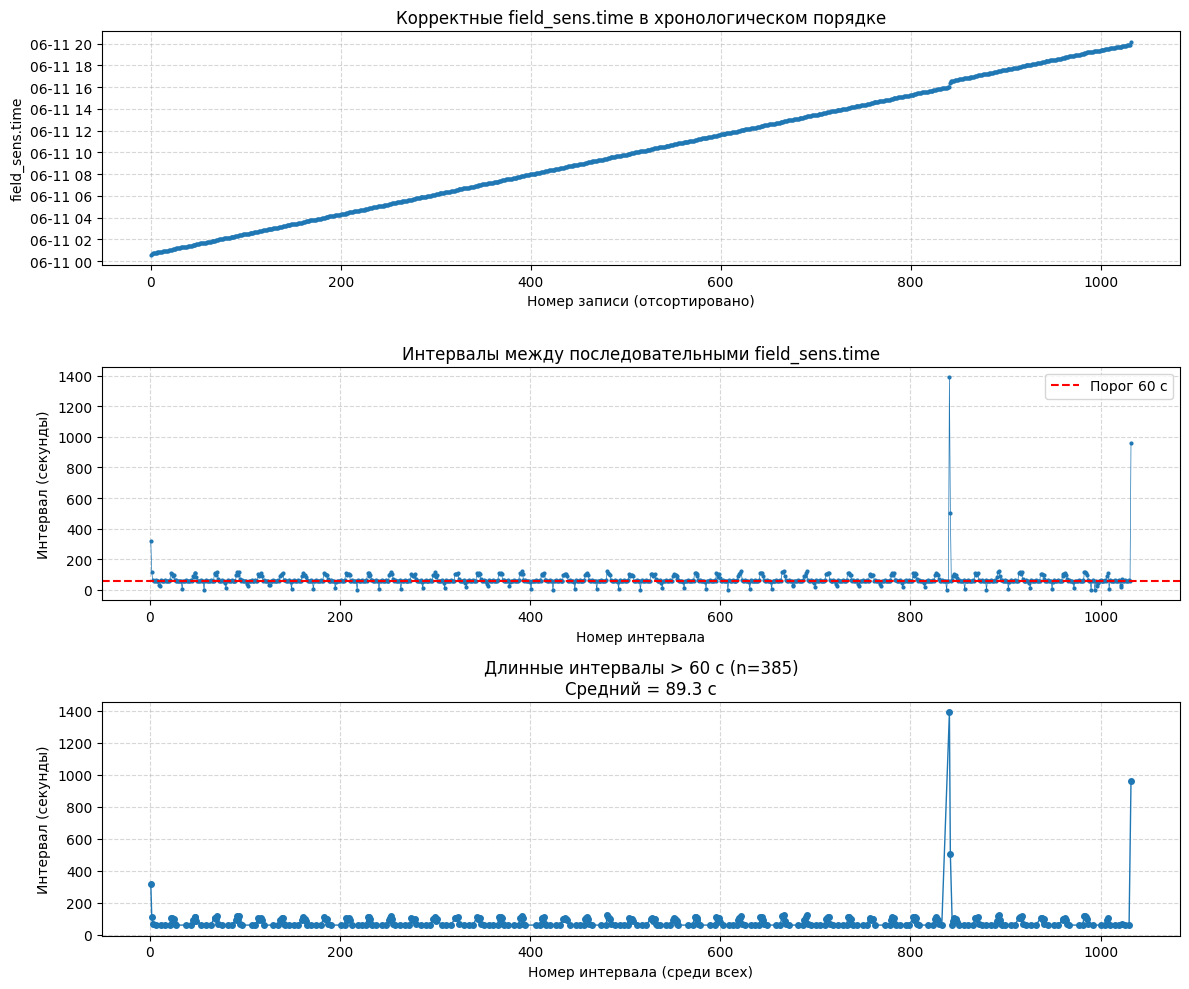

In [8]:
import json
import matplotlib.pyplot as plt
from datetime import datetime

def parse_field_sens_times(file_path):
    """Извлекает field_sens.time, фильтрует невалидные (2000-00-00, 2070-01-01)."""
    times = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                data = json.loads(line)
                if 'field_sens' in data and 'time' in data['field_sens']:
                    ts_str = data['field_sens']['time']
                    # Пропускаем заведомо неверные метки
                    if ts_str.startswith('2000-00-00') or ts_str.startswith('2070-01-01'):
                        continue
                    times.append(datetime.fromisoformat(ts_str))
            except:
                continue
    times.sort()
    return times

def compute_intervals(times):
    """Интервалы в секундах между последовательными временами."""
    return [(times[i] - times[i-1]).total_seconds() for i in range(1, len(times))]

def plot_line_graphs(times, intervals, threshold=3600):
    plt.figure(figsize=(12, 10))

    # 1. Временные метки по порядку
    plt.subplot(3, 1, 1)
    plt.plot(range(len(times)), times, 'o-', markersize=2, linewidth=0.5)
    plt.xlabel('Номер записи (отсортировано)')
    plt.ylabel('field_sens.time')
    plt.title('Корректные field_sens.time в хронологическом порядке')
    plt.grid(True, linestyle='--', alpha=0.5)

    # 2. Все интервалы (логарифмическая шкала)
    plt.subplot(3, 1, 2)
    plt.plot(range(1, len(intervals)+1), intervals, 'o-', markersize=2, linewidth=0.5)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'Порог {threshold} с')
    plt.xlabel('Номер интервала')
    plt.ylabel('Интервал (секунды)')
    plt.title('Интервалы между последовательными field_sens.time')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)

    # 3. Только интервалы > порога
    plt.subplot(3, 1, 3)
    long_intervals = [i for i in intervals if i > threshold]
    if long_intervals:
        indices = [idx+1 for idx, val in enumerate(intervals) if val > threshold]
        plt.plot(indices, long_intervals, 'o-', markersize=4, linewidth=1)
        plt.xlabel('Номер интервала (среди всех)')
        plt.ylabel('Интервал (секунды)')
        plt.title(f'Длинные интервалы > {threshold} с (n={len(long_intervals)})\nСредний = {sum(long_intervals)/len(long_intervals):.1f} с')
        plt.grid(True, linestyle='--', alpha=0.5)
    else:
        plt.text(0.5, 0.5, f'Нет интервалов больше {threshold} с', ha='center', va='center')

    plt.tight_layout()
    plt.show()

def main():
    file_path = 'data_decoded.txt'
    times = parse_field_sens_times(file_path)
    print(f"Найдено корректных field_sens.time: {len(times)}")

    if len(times) < 2:
        print("Недостаточно данных для построения.")
        return

    intervals = compute_intervals(times)
    print(f"Всего интервалов: {len(intervals)}")
    if intervals:
        print(f"Минимальный интервал: {min(intervals):.2f} с")
        print(f"Максимальный интервал: {max(intervals):.2f} с")
        print(f"Средний интервал: {sum(intervals)/len(intervals):.2f} с")
        print(f"Медианный интервал: {sorted(intervals)[len(intervals)//2]:.2f} с")

    # Порог можно подобрать исходя из данных (например, 1 час = 3600 с)
    threshold = 60
    plot_line_graphs(times, intervals, threshold)

if __name__ == "__main__":
    main()